## IN_DATA
- `dat_minimap_traj`

## OUT_DATA
- `idx_masked_map_{job_id}`

## VERSION

## PACKAGE

In [1]:
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.metadata import *
from src.sparsemap import *

warnings.filterwarnings("ignore", category=RuntimeWarning)

## BASH PARAMETERS

In [2]:
in_dir = project_dir / "results"
out_dir = project_dir / "results" / "data_map"
#
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

In [3]:
# load tile trajectories
dat_traj_dict = pickle.load(open(in_dir / "dat_traj_dict", "rb"))

## SPECIFY ONE JOB BATCH
1. Select a subset of `dat_traj_dict` with a `pi_level` as a batch of jobs to run on cluster
2. the key for reading `dat_traj_dict` is `(type_id, id_1, id_2)` to output the value `(s_traj, a_traj, occ_map, s_top, xy_traj)`
3. for loading a mouse trajectory, use:
    - `type_id = 1`
    - `id_1` = 3 or 4 or ... (mouse_id)
    - `id_2` = 0 or 1 ... or 5 (rotation_id)
4. for loading a random trajectory, use:
    - `type_id = 0`
    - `id_1` = 0 or 1 or ... (seed)
    - `id_2` = -1 (-1 to specify n/a)
5. load a job as a nested tuple `((type_id, id_1, id_2), pi_level)`

In [4]:
# PILOT BATCH: one pi_level, 6 traj for one mouse + 5 random trajectories
pi_level = 80
job_batch = {
    1: ((0,0,-1), pi_level), 
    2: ((0,1,-1), pi_level), 
    3: ((0,2,-1), pi_level), 
    4: ((0,3,-1), pi_level), 
    5: ((0,4,-1), pi_level),
    6: ((1,3,0), pi_level), 
    7: ((1,3,1), pi_level), 
    8: ((1,3,2), pi_level), 
    9: ((1,3,3), pi_level), 
    10: ((1,3,4), pi_level), 
    11: ((1,3,5), pi_level)
}

## LOCAL PARAMETERS

In [5]:
debug = False
n_parallel = 25

## PREP
### setting up belief distribution propagation

In [6]:
# prep: maze dictionaries
hex_0_grid, hex_1_grid, s_z_dict, s_hex_dict, hex_a_dict, xy_s_dict, a_dict, sas_dict, ssa_dict, s_nbr_dict = load_maze_dicts(maze)

# prep: map
sh_dz_arr = get_sh_dz_arr(s_z_dict, sas_dict)
e_sh_arr = get_e_sh_arr(n_tiles, ringsize)
pq_mask_amb_dict = get_pq_mask_dict_for_ambiguous_edges(sh_dz_arr)

# prep: pi & tile transition tensor
pi_all = get_p_vonmises_for_enumPI()
T = get_T_tensor(sas_dict, ringsize, n_tiles)
T_dict = get_T_tensor_dict(T, ringsize)

## LOAD ONE JOB

In [7]:
job_id = 6#int(sys.argv[1])

In [8]:
key, pi_level = job_batch[job_id]
s_traj, a_traj, occ_map, s_top, xy_traj = dat_traj_dict[key]
pi = pi_all[pi_level]

## RUN: map optimization

In [26]:
def run_map_optimizer(s_traj, a_traj, s_top, pi, schedule):
    '''
    NOTE: 
    '''
    # mp
    def run_mp(param):
        # load
        map, chunk_id, chunksize = param
        
        # load chunk of trajectory
        if chunk_id is None:
            s_traj_r, a_traj_r = s_traj, a_traj
        else:
            s_traj_r = s_traj[chunk_id*chunksize:(chunk_id+1)*chunksize]
            a_traj_r = a_traj[chunk_id*chunksize:(chunk_id+1)*chunksize]
        
        # eval
        score, score_map = eval_one_map(map, s_traj_r, a_traj_r, s_top, T_dict, pi, e_sh_arr, pq_mask_amb_dict, n_tiles, ringsize, n_edges, sh_dz_arr)
        return score, score_map
    
    # eval full map
    score_max, _ = run_mp((np.arange(n_edges), None, None))

    # initialize
    eid_removed = []
    # eid_remain = np.argsort(occ_map[e_sh_arr[:,0]]) # all edges sorted from least to most occupied (by tile occupancy)
    eid_remain = np.arange(n_edges)
    score_iter = [score_max]

    # iter
    for iter, (n_chunks, chunk_id, chunksize) in schedule.items():        
        # eval candidates on one traj chunk
        eid_remain_cand = [eid_remain[eid_remain!=x] for x in eid_remain]
        param = [(x, chunk_id, chunksize) for x in eid_remain_cand]
        with multiprocess.Pool() as p:
            score_cand, _ = zip(*p.map(run_mp, param))
        
        # find top 
        idx_top = np.argmax(score_cand)
        eid_top = eid_remain[idx_top] # top to be removed
        score_top = score_cand[idx_top]
        eid_remain = eid_remain_cand[idx_top]

        # append
        eid_removed.append(eid_top)
        score_iter.append(score_top)
        
        # print
        print(f"iter {iter}: remove edge {eid_top}, score = {score_top:.6f}, n_chunks = {n_chunks}, chunk_id = {chunk_id}")
    return score_iter, eid_removed

def eval_multiple_maps(map_list, s_traj, a_traj, s_top, pi):
    '''
    NOTE: 
    '''
    def run_mp(map):
        score, score_map = eval_one_map(map, s_traj, a_traj, s_top, T_dict, pi, e_sh_arr, pq_mask_amb_dict, n_tiles, ringsize, n_edges, sh_dz_arr)
        return score, score_map
    
    # mp
    with multiprocess.Pool() as p:
        score_list, score_map_list = zip(*p.map(run_mp, map_list))
    score_list = np.array(score_list)
    return score_list, score_map_list

In [10]:
## RUN (100m)
# get optimization schedule
schedule = get_optimization_schedule(n_parallel, n_edges, s_traj)
schedule = {x:schedule[x] for x in range(5)} # TEST RUN

# run optimization
score_iter, eid_removed = run_map_optimizer(s_traj, a_traj, s_top, pi, schedule)

# eval all maps on full trajectory
print('evaluating all maps on full trajectory...')
map_iter = get_map_list_from_eid_removed(eid_removed, n_edges)
score_iter_full, score_map_iter_full = eval_multiple_maps(map_iter, s_traj, a_traj, s_top, pi)

iter 0: remove edge 5, score = 0.986564, n_chunks = 37, chunk_id = 0
iter 1: remove edge 2, score = 0.973729, n_chunks = 37, chunk_id = 1
iter 2: remove edge 21, score = 0.986703, n_chunks = 37, chunk_id = 2
iter 3: remove edge 6, score = 0.986972, n_chunks = 37, chunk_id = 3
iter 4: remove edge 10, score = 0.999816, n_chunks = 37, chunk_id = 4
evaluating all maps on full trajectory...


In [14]:
score_iter

[0.9996534181411705,
 0.9865641061221043,
 0.9737286852436123,
 0.9867026479525847,
 0.9869715359717564,
 0.9998156256233752]

In [13]:
score_iter_full

(0.9996534181411705,
 0.9996533825918763,
 0.9996533781536516,
 0.9996533778679672,
 0.9996528715486837,
 0.9996524164387517)

## PICKLE

In [18]:
dat_map = score_iter_full, score_map_iter_full, eid_removed
dat_path = out_dir / f"dat_map_{job_batch[job_id]}"
pickle.dump(dat_map, open(dat_path, "wb"))

In [ ]:
# check if the saved file exists
os.path.exists(dat_path)

## TEST

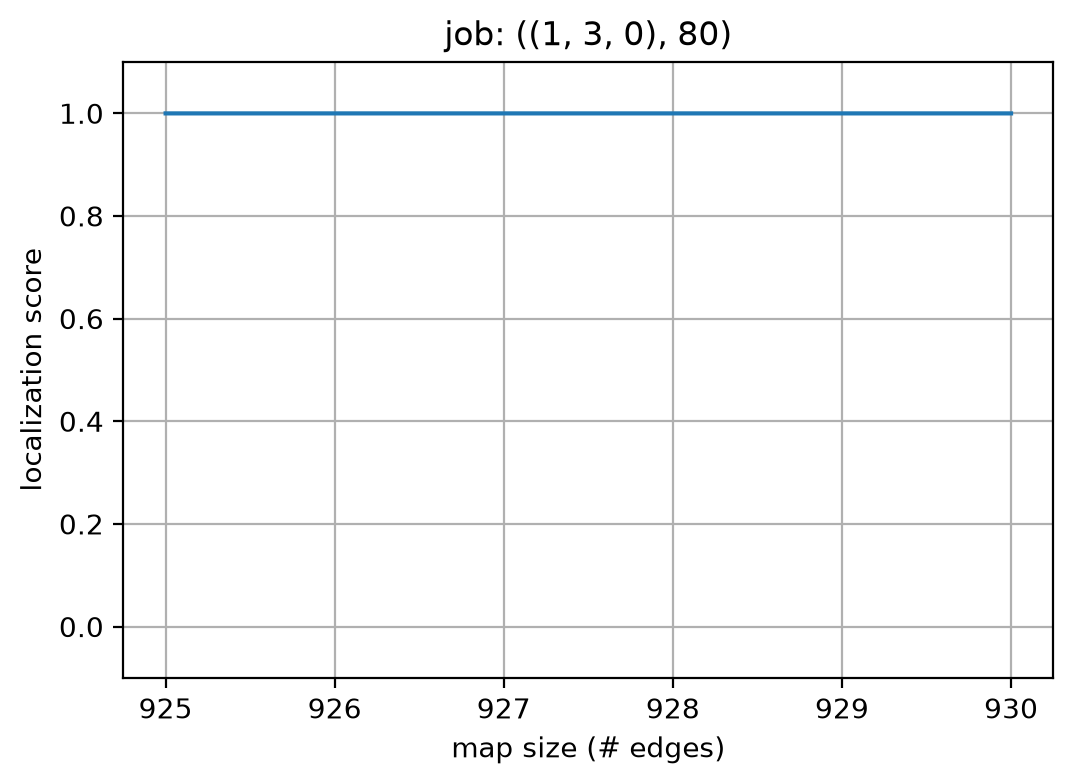

In [32]:
n_plot = 600

# plot
mapsize_iter = [len(x) for x in map_iter]
plt.figure(figsize=(6,4), dpi=200)
plt.title(f"job: {job_batch[job_id]}")
plt.plot(mapsize_iter[:n_plot], score_iter_full[:n_plot])
plt.xlabel('map size (# edges)')
plt.ylabel('localization score')
plt.ylim([-.1,1.1])
plt.grid()

## RUN SINGLE: eval on one (traj, pi, map)

In [ ]:
if debug:
    # load traj
    s_traj, a_traj, occ_map, s_top, _ = dat_traj_dict[(1, 3, 0)]
    # s_traj, a_traj, occ_map, s_top, _ = dat_traj_dict[(0, 3, -1)]
    # s_traj = np.array([37,50,63,76,89,102,115,127,128,129,130,131])
    # a_traj = np.array([-1,1,1,1,1,1,1,1,0,0,0,0])

    # load pi
    idx_pi = 90
    pi = pi_all[idx_pi]
    sap_arr = get_sap_arr(pi_all[100], sas_dict, ringsize, n_tiles) # pq_prop_v1

    # load map
    np.random.seed(42)
    map = np.random.permutation(n_edges)[:30]

    # prep: pq_mask from map
    # pq_mask_dict = get_pq_mask_dict_for_one_map(map, e_sh_arr, pq_mask_amb_dict, n_tiles, ringsize, n_edges)
    s_pq_mask_dict = get_s_pq_mask_dict_for_one_map(map, e_sh_arr, pq_mask_amb_dict, n_tiles, ringsize, n_edges, sh_dz_arr)

In [ ]:
if debug:
    # pq_prop
    pq_traj = pq_prop_for_n_steps(s_traj, a_traj, T_dict, pi, s_pq_mask_dict, n_tiles, ringsize, sh_dz_arr)
    score_map, score = get_score_map(s_traj, pq_traj.sum(-1), s_top)

    # pq_prop_v1
    # p_traj, q_traj = pq_prop_for_n_steps_v1(s_traj, a_traj, sap_arr, pi, pq_mask_dict, n_tiles, ringsize, sh_dz_arr)

    # print
    score

0.8318019290459837

## TEST SINGLE

### pq_traj

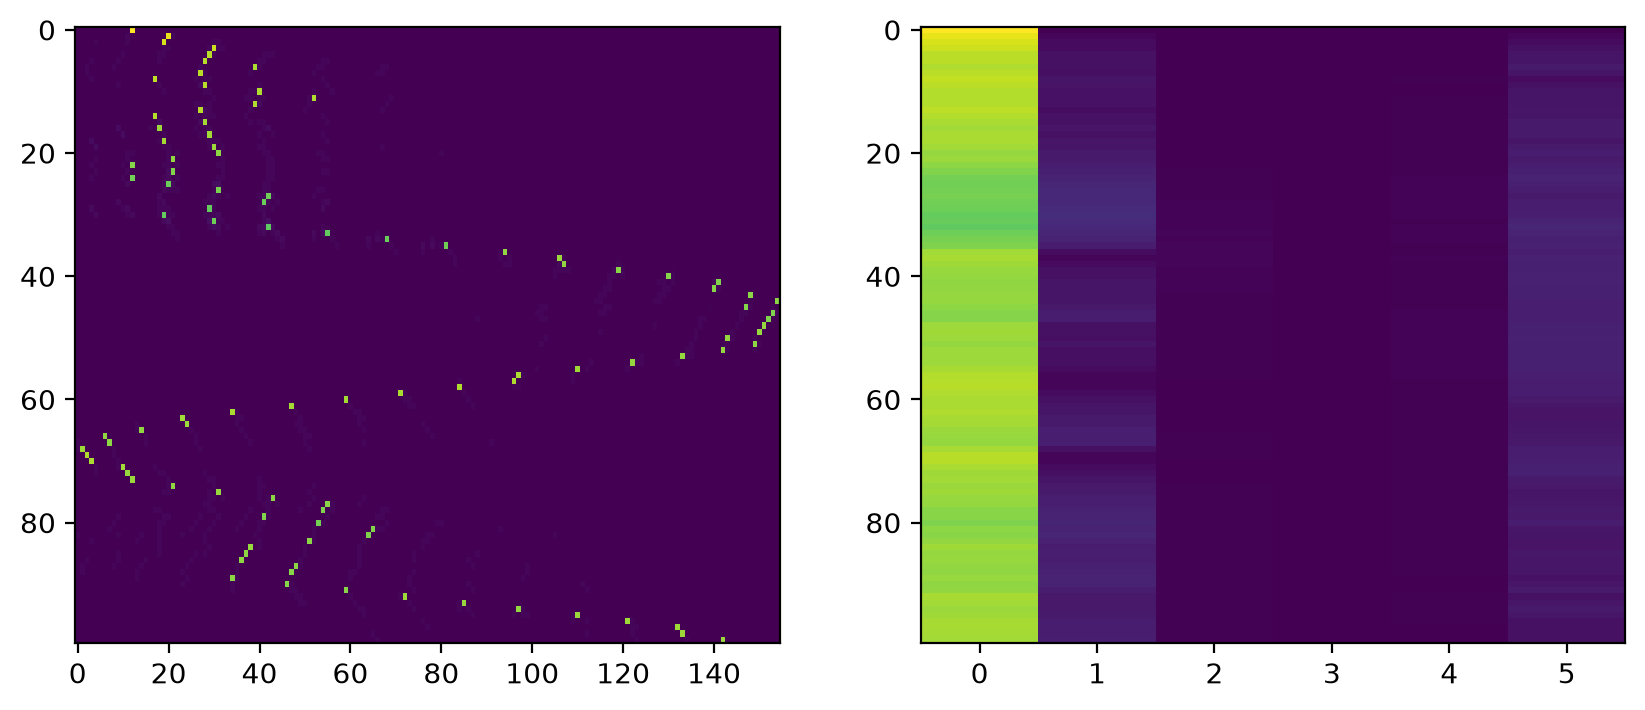

In [ ]:
if debug:
    plt.figure(figsize=(10,4), dpi=200)
    plt.subplot(1,2,1)
    plt.imshow(pq_traj.sum(-1)[:100], aspect='auto')
    plt.subplot(1,2,2)
    plt.imshow(pq_traj.sum(1)[:100], aspect='auto')

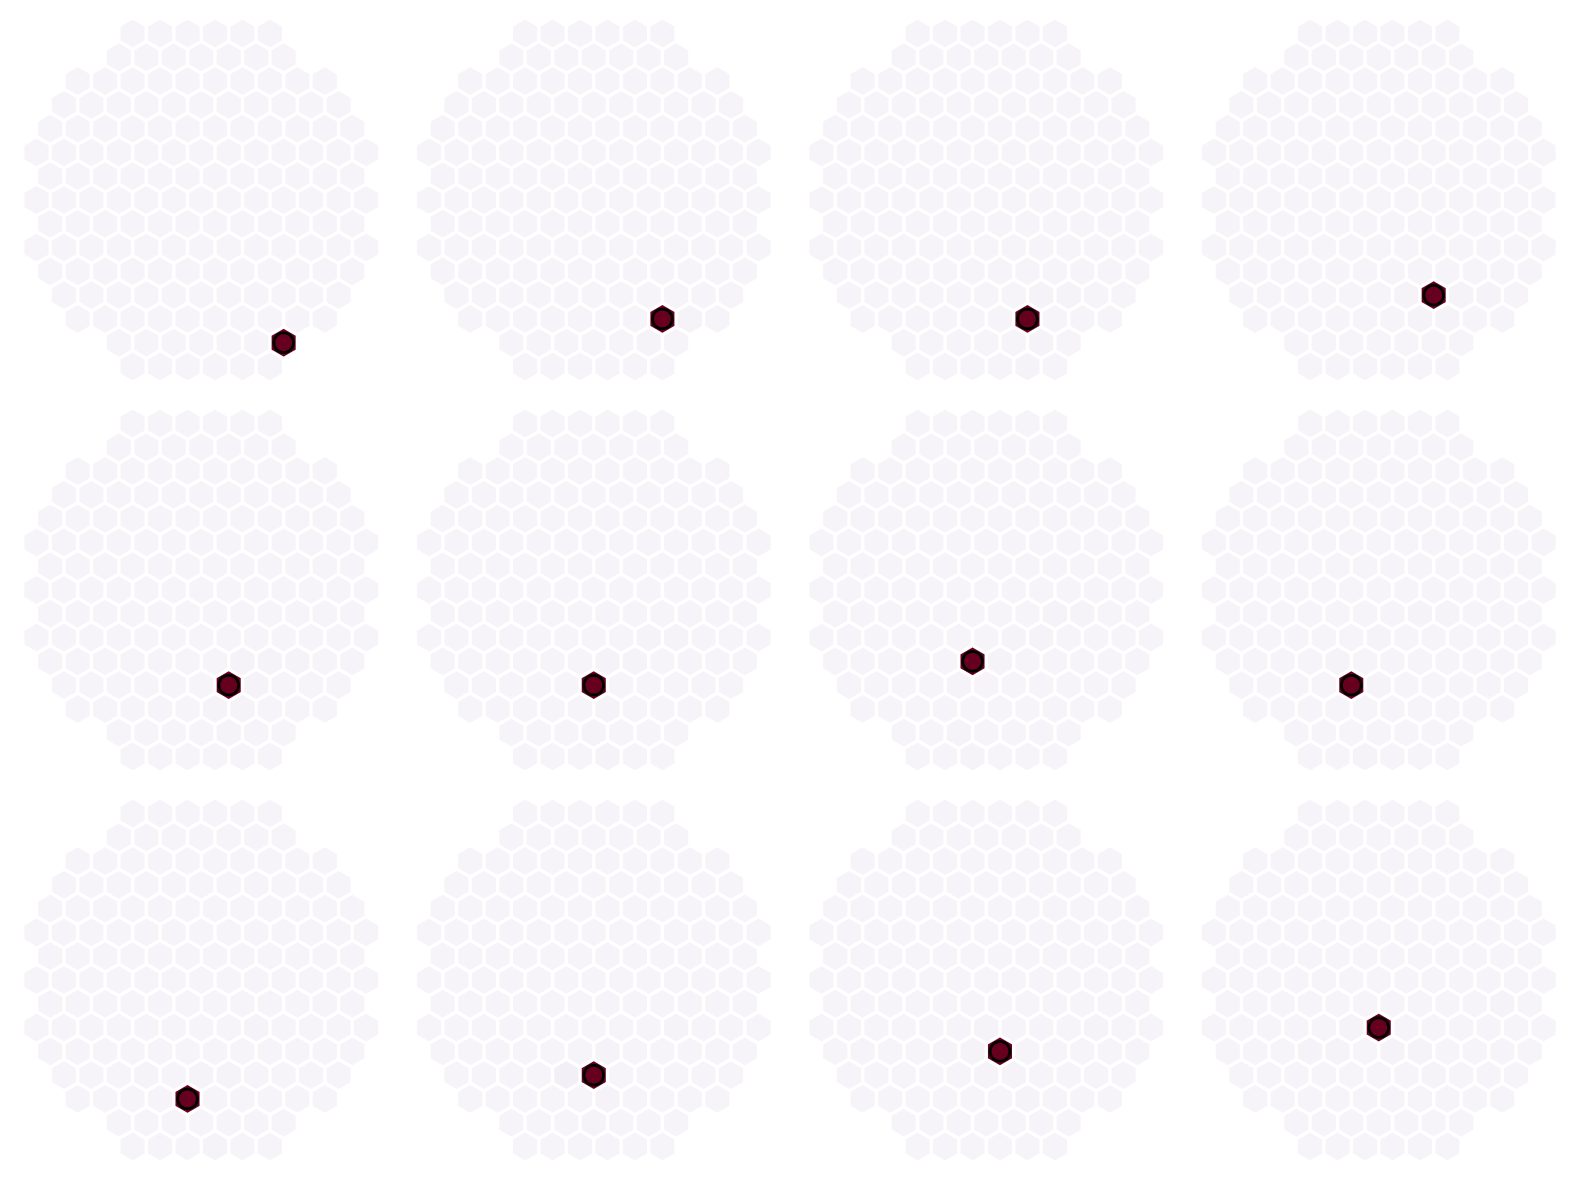

In [ ]:
if debug:
    # prep
    s_count = [Counter(s_traj)[x] for x in range(n_tiles)]
    hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T
    hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T

    # plot
    plt.figure(figsize=(8,6), dpi=200)
    i = 0
    for t in range(0,12):
        i+=1
        plt.subplot(3,4,i)
        # plt.title(f'random walk ({seed}); top half occupied: {len(s_top)} tiles')
        # map
        s = s_traj[t]
        plt.scatter(hex_0_all, hex_1_all, c=pq_traj[t].sum(-1), cmap='PuRd', marker='h', s=100, vmin=0, edgecolor='none')
        plt.scatter([hex_0_all[s]], [hex_1_all[s]], s=50, edgecolor='k', facecolor='none')
        # for (x,y), s in xy_s_dict.items():
        #     plt.text(hex_0_grid[y,x], hex_1_grid[y,x], str(s), color='dimgray', fontsize=6, ha='center', va='center')

        # setting
        plt.axis('off')
        plt.axis('equal')
    plt.tight_layout()

### score map

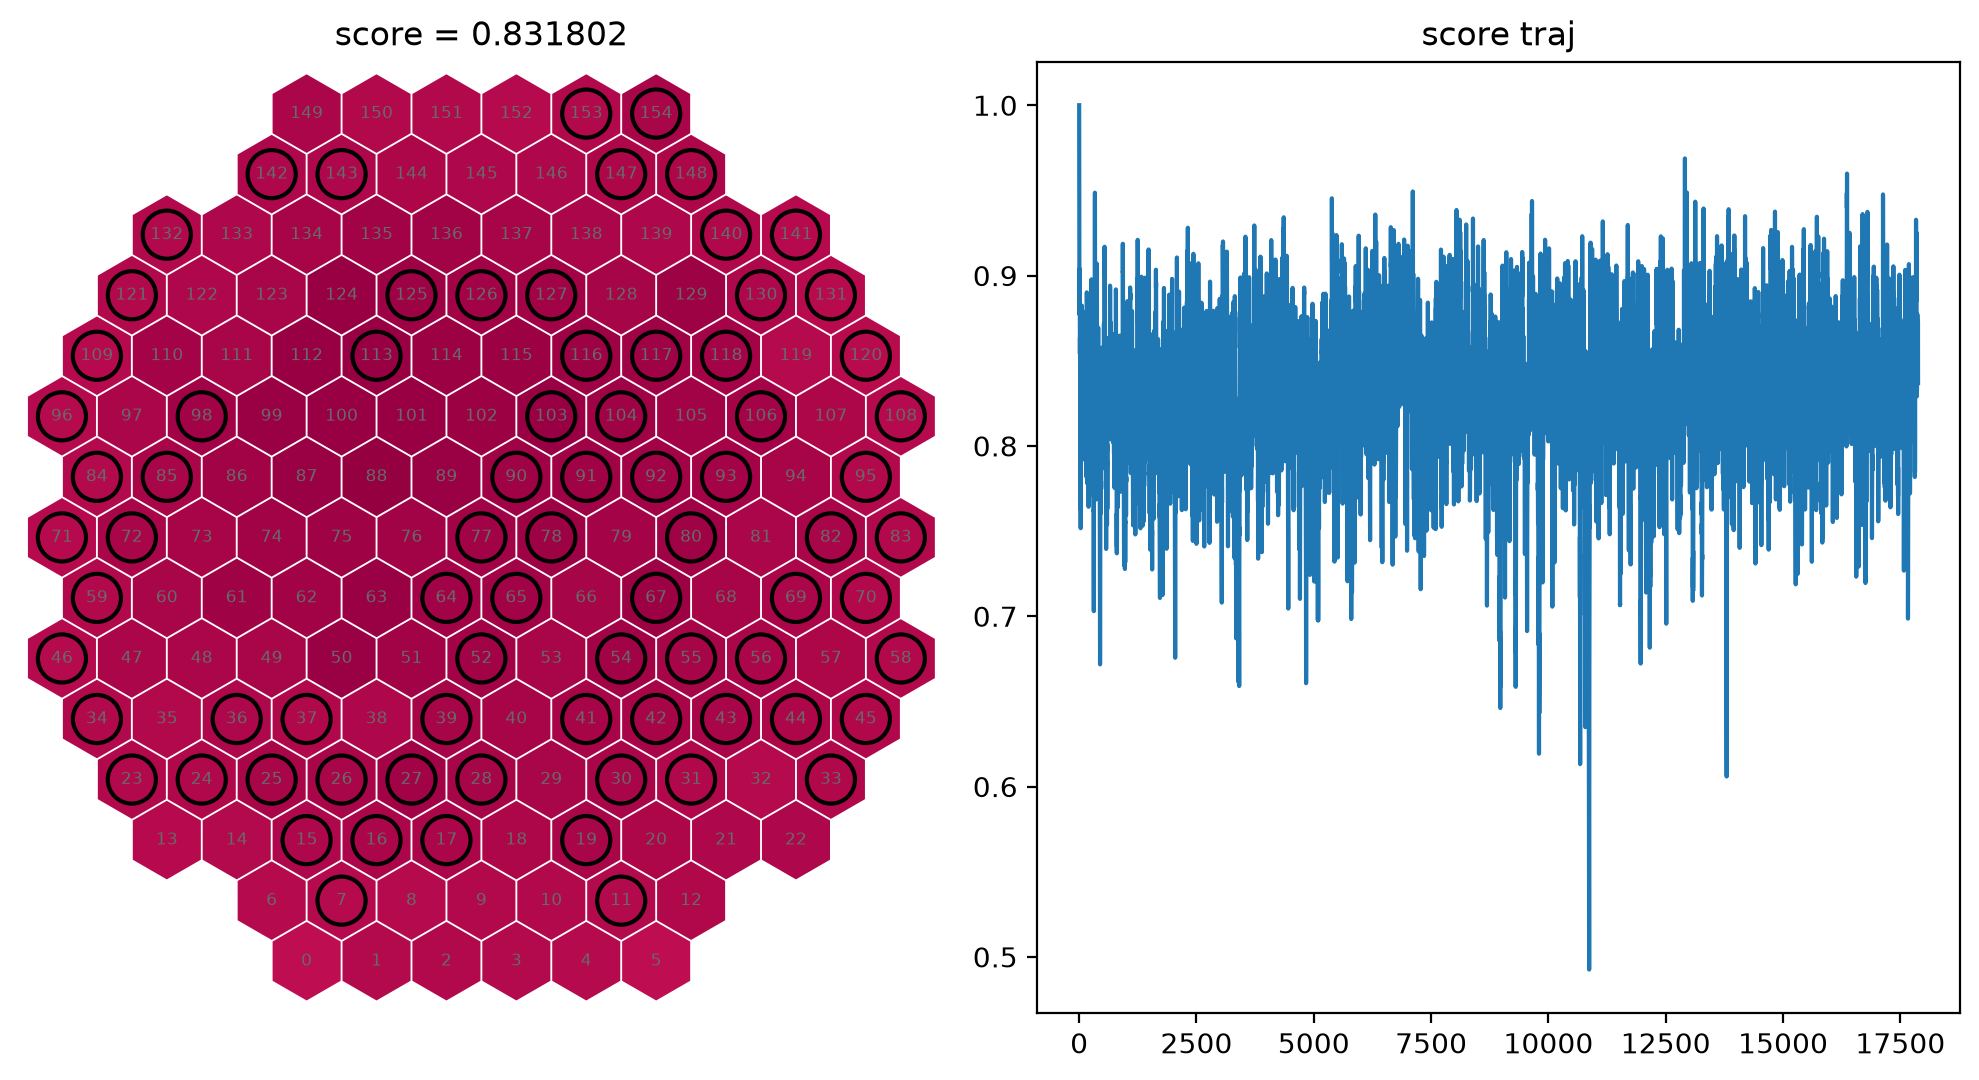

In [ ]:
if debug:
    # prep
    s_count = [Counter(s_traj)[x] for x in range(n_tiles)]
    hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T
    hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T

    # plot
    plt.figure(figsize=(10,5.5), dpi=200)

    plt.subplot(121)
    plt.title(f'score = {score:.6f}')
    plt.scatter(hex_0_all, hex_1_all, c=score_map, cmap='PuRd', marker='h', s=800, vmin=0, vmax=1, edgecolor='none')
    # plot s_top in circular markers
    plt.scatter(hex_0_all[s_top], hex_1_all[s_top], s=300, edgecolor='k', facecolor='none', marker='o', linewidth=1.5)
    for (x,y), s in xy_s_dict.items():
        plt.text(hex_0_grid[y,x], hex_1_grid[y,x], str(s), color='dimgray', fontsize=6, ha='center', va='center')
    # setting
    plt.axis('off')
    plt.axis('equal')
    plt.tight_layout()

    plt.subplot(122)
    plt.title('score traj')
    plt.plot(pq_traj.sum(-1).max(1))

    plt.tight_layout()

## SPEED TEST

### new scheduled optimizer is 3x faster & find better performing maps

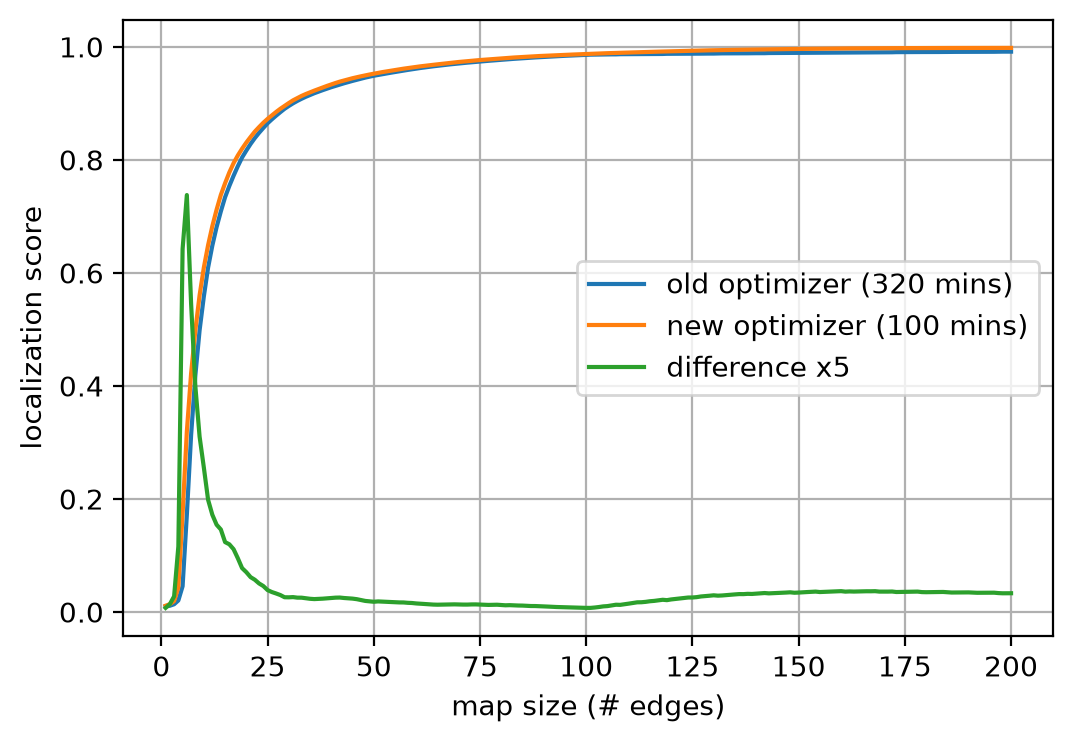

In [ ]:
# job param
# type_id, id_1, id_2 = 1, 3, 2
# pi_level = 90

# load
score_iter_0, score_map_iter_0, eid_removed_0 = pickle.load(open(out_dir / "dat_test", "rb")) # old optimizer (320 mins)
score_iter, score_map_iter, eid_removed = pickle.load(open(out_dir / "dat_test_2", "rb")) # new optimizer (100 mins)

# plot
n_plot = 200
mapsize_iter = [len(x) for x in get_map_list_from_eid_removed(eid_removed)]
plt.figure(figsize=(6,4), dpi=200)
plt.plot(mapsize_iter[:n_plot], score_iter_0[::-1][:n_plot], label='old optimizer (320 mins)')
plt.plot(mapsize_iter[:n_plot], score_iter_full[:n_plot], label='new optimizer (100 mins)')
difference = score_iter_full[:n_plot]-np.array(score_iter_0)[::-1][:n_plot]
plt.plot(mapsize_iter[:n_plot], difference * 5, label='difference x5')
plt.xlabel('map size (# edges)')
plt.ylabel('localization score')
plt.grid()
plt.legend()

### map optimized from rotated traj compresses worse (expected)

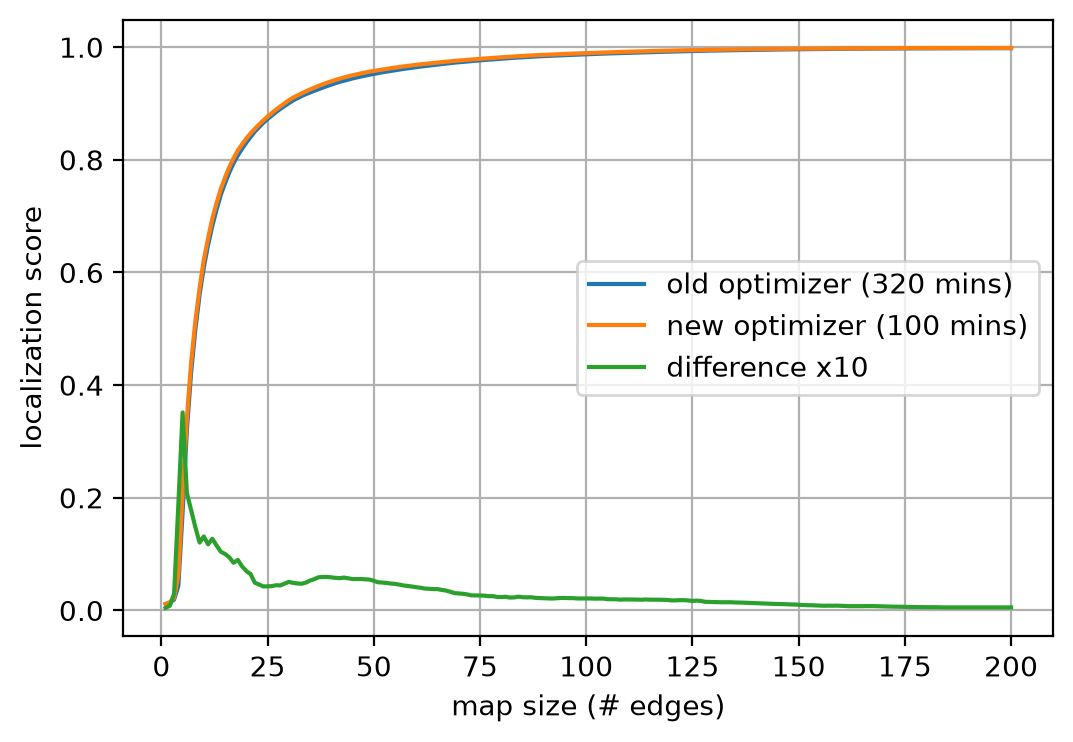

In [23]:
# job param
# type_id, id_1, id_2 = 1, 3, 0
# pi_level = 90

# load
score_iter_2, score_map_iter_2, eid_removed_2 = pickle.load(open(out_dir / "dat_test_2", "rb")) # old optimizer (320 mins)
score_iter_3, score_map_iter_3, eid_removed_3 = pickle.load(open(out_dir / "dat_test_3", "rb")) # new optimizer (100 mins)

# plot
n_plot = 200
mapsize_iter = [len(x) for x in get_map_list_from_eid_removed(eid_removed_2)]
plt.figure(figsize=(6,4), dpi=200)
plt.plot(mapsize_iter[:n_plot], score_iter_2[:n_plot], label='old optimizer (320 mins)')
plt.plot(mapsize_iter[:n_plot], score_iter_3[:n_plot], label='new optimizer (100 mins)')
difference = score_iter_3[:n_plot]-np.array(score_iter_2)[:n_plot]
plt.plot(mapsize_iter[:n_plot], difference * 10, label='difference x10')
plt.xlabel('map size (# edges)')
plt.ylabel('localization score')
plt.grid()
plt.legend()

### how n_parallel affect runtime (compute budget)

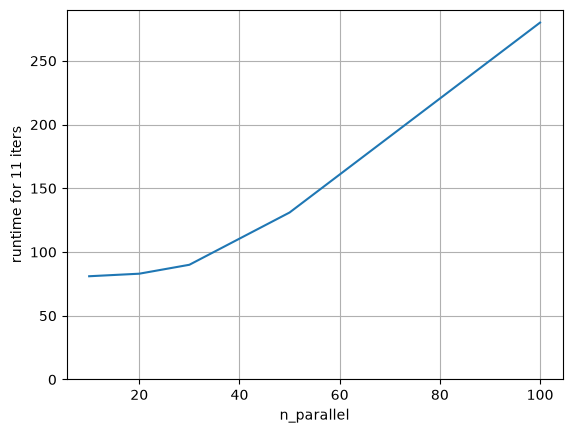

In [ ]:
if debug:
    # test results (11 iters)
    n_parallel_tested = np.array([10,20,30,50,100])
    runtime_tested = np.array([81,83,90,131,280])
    runtime_single_core = n_parallel_tested * 4 * 11

    # plot
    plt.plot(n_parallel_tested, runtime_tested)
    # plt.plot(n_parallel_tested, runtime_single_core, color='r', linestyle='--', label='4 sec per iter')
    plt.xlabel('n_parallel')
    plt.ylabel('runtime (s) for 11 iters')
    plt.ylim(0,None)
    plt.grid()

In [ ]:
if debug:
    pq0 = np.zeros([n_tiles, ringsize])
    pq0[s_traj[0], 0] = 1
    pq_mask = s_pq_mask_dict[77]

In [ ]:
# %%timeit
# pq1 = pq0 * pq_mask
# # pq1 / pq1.sum()

# # 1.4 μs ± 4.06 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)

1.4 μs ± 4.06 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [ ]:
# %%timeit
# collapse_pq_one_step(pq0, s_traj[0], s_pq_mask_dict, ringsize, sh_dz_arr)

# # 3.26 μs ± 51.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)

3.26 μs ± 51.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [ ]:
# %%timeit
# collapse_pq_one_step(pq0, s_traj[0], s_pq_mask_dict, ringsize, sh_dz_arr)

# # 3.26 μs ± 13.1 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)

3.26 μs ± 13.1 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [ ]:
# ## n_chunks = 50 (46s)
# iter 0: remove edge 928, score = 0.999555, n_cand_per_iter = 930
# iter 1: remove edge 927, score = 0.960888, n_cand_per_iter = 930
# iter 2: remove edge 926, score = 0.97387, n_cand_per_iter = 930
# iter 3: remove edge 648, score = 0.999984, n_cand_per_iter = 930
# iter 4: remove edge 649, score = 0.960744, n_cand_per_iter = 930
# iter 5: remove edge 650, score = 0.947987, n_cand_per_iter = 930
# iter 6: remove edge 651, score = 0.99998, n_cand_per_iter = 930
# iter 7: remove edge 653, score = 0.934834, n_cand_per_iter = 930
# iter 8: remove edge 851, score = 0.934804, n_cand_per_iter = 930
# iter 9: remove edge 850, score = 0.934897, n_cand_per_iter = 930

# ## n_chunks = 30 (69s)
# iter 0: remove edge 928, score = 0.999658, n_cand_per_iter = 930
# iter 1: remove edge 927, score = 0.999837, n_cand_per_iter = 930
# iter 2: remove edge 925, score = 0.99988, n_cand_per_iter = 930
# iter 3: remove edge 648, score = 0.999954, n_cand_per_iter = 930
# iter 4: remove edge 649, score = 0.999855, n_cand_per_iter = 930
# iter 5: remove edge 650, score = 0.999768, n_cand_per_iter = 930
# iter 6: remove edge 651, score = 0.999691, n_cand_per_iter = 930
# iter 7: remove edge 653, score = 0.960737, n_cand_per_iter = 930
# iter 8: remove edge 851, score = 0.960787, n_cand_per_iter = 930
# iter 9: remove edge 850, score = 0.999607, n_cand_per_iter = 930

# ## n_chunks = 10 (184s)
# iter 0: remove edge 928, score = 0.999788, n_cand_per_iter = 930
# iter 1: remove edge 927, score = 0.999857, n_cand_per_iter = 930
# iter 2: remove edge 926, score = 0.999757, n_cand_per_iter = 930
# iter 3: remove edge 648, score = 0.99978, n_cand_per_iter = 930
# iter 4: remove edge 649, score = 0.999791, n_cand_per_iter = 930
# iter 5: remove edge 650, score = 0.999825, n_cand_per_iter = 930
# iter 6: remove edge 651, score = 0.999783, n_cand_per_iter = 930
# iter 7: remove edge 653, score = 0.999784, n_cand_per_iter = 930
# iter 8: remove edge 851, score = 0.999772, n_cand_per_iter = 930
# iter 9: remove edge 850, score = 0.999653, n_cand_per_iter = 930